# 07 - New Product Launch

## Purpose

Explore how HealthSynth simulates a new pharmaceutical product entering an established market.

This notebook demonstrates how:

- a product remains unavailable before launch
- adoption develops gradually after launch
- promotional activity accelerates adoption
- market share is sourced from competing products
- market-share changes flow through to prescription volume

The objective is not only to inspect the generated datasets, but to understand the commercial dynamics that produce them.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from healthsynth.generator import generate

In [2]:
datasets = generate(
    config_path="../configs/profiles/oncology_product_launch.yaml",
    output_dir="../output/new_product_launch_analysis",
)

In [3]:
products = datasets["product"]
market_share = datasets["market_share"]
prescriptions = datasets["prescriptions"]
call_activity = datasets["call_activity"]
promotion_effect = datasets["promotion_effect"]
market_demand = datasets["market_demand"]

## The Commercial Scenario

The simulated oncology market contains two established products and one new entrant.

The new product, NovaMab, launches during the simulation period rather than being available from the beginning.

HealthSynth models the launch as a sequence of connected commercial effects:

```text
Product Launch
        ↓
Product Availability
        ↓
Gradual Adoption
        ↓
Promotion Acceleration
        ↓
Market Share Gain
        ↓
Competitor Share Loss
        ↓
Prescription Allocation

In [4]:
product_columns = [
    "product_id",
    "product_name",
    "manufacturer",
    "brand_type",
    "launch_date",
    "baseline_market_share",
    "adoption_curve",
    "adoption_months",
    "launch_share_factor",
    "promotion_adoption_weight",
]

products[product_columns]

,product_id,product_name,manufacturer,brand_type,launch_date,baseline_market_share,adoption_curve,adoption_months,launch_share_factor,promotion_adoption_weight
0,P001,OncoNova,NVA Pharma,Innovator,2022-01-01,0.45,NaN,NaN,NaN,NaN
1,P002,Tumora,Helix Therapeutics,Competitor,2022-07-01,0.35,NaN,NaN,NaN,NaN
2,P003,NovaMab,Apex Oncology,Innovator,2023-05-01,0.20,linear,8.0,0.1,0.25


The product portfolio represents three different commercial positions:

- **OncoNova (P001)** is the established market leader.
- **Tumora (P002)** is an existing competitor.
- **NovaMab (P003)** is the new product launch.

NovaMab has a configured baseline market share of 20%, but it does not receive that share immediately.

Instead, its launch settings describe how it moves toward its full commercial potential:

- `launch_date` controls when the product becomes available.
- `launch_share_factor` controls its initial level of adoption.
- `adoption_months` controls how long it takes to reach full adoption.
- `promotion_adoption_weight` controls how strongly promotional activity accelerates adoption.

The configured baseline share therefore represents mature competitive potential rather than launch-month share.

In [5]:
market_share["month"] = pd.to_datetime(market_share["month"])

prescriptions["rx_date"] = pd.to_datetime(prescriptions["rx_date"])

products["launch_date"] = pd.to_datetime(products["launch_date"])

launch_product_id = "P003"

launch_date = products.loc[
    products["product_id"] == launch_product_id,
    "launch_date",
].iloc[0]

launch_date

Timestamp('2023-05-01 00:00:00')

## Product Availability Before and After Launch

A product should not participate in the commercial market before it becomes available.

For NovaMab, the configured launch date is **May 1, 2023**.

Before that month, HealthSynth should generate:

- zero market share
- zero prescriptions
- no promotional calls

From the launch month onward, NovaMab becomes commercially active and begins its adoption journey.

In [6]:
launch_market_share = market_share[market_share["product_id"] == launch_product_id].copy()

launch_market_share[
    [
        "month",
        "base_adoption_factor",
        "promotion_acceleration",
        "effective_adoption_factor",
        "adjusted_market_share",
    ]
].head(8)

,month,base_adoption_factor,promotion_acceleration,effective_adoption_factor,adjusted_market_share
2,2023-03-01,0.0000,0.000000,0.000000,0.000000
5,2023-04-01,0.0000,0.000000,0.000000,0.000000
8,2023-05-01,0.1000,0.156583,0.256583,0.069324
11,2023-06-01,0.2125,0.126341,0.338841,0.081627
14,2023-07-01,0.3250,0.088443,0.413443,0.107709
17,2023-08-01,0.4375,0.065642,0.503142,0.128991
20,2023-09-01,0.5500,0.074472,0.624472,0.152269
23,2023-10-01,0.6625,0.050571,0.713071,0.161039


In [7]:
pre_launch_share = launch_market_share[launch_market_share["month"] < launch_date]

assert (pre_launch_share["adjusted_market_share"] == 0.0).all()

print(
    "Pre-launch market share is zero:",
    True,
)

Pre-launch market share is zero: True


In [8]:
launch_prescriptions = prescriptions[prescriptions["product_id"] == launch_product_id].copy()

pre_launch_nrx = launch_prescriptions[launch_prescriptions["rx_date"] < launch_date]["nrx"].sum()

assert pre_launch_nrx == 0

print(
    "Pre-launch NovaMab NRx:",
    pre_launch_nrx,
)

Pre-launch NovaMab NRx: 0


In [9]:
call_activity["call_date"] = pd.to_datetime(call_activity["call_date"])

pre_launch_calls = call_activity[
    (call_activity["product_id"] == launch_product_id) & (call_activity["call_date"] < launch_date)
]

assert pre_launch_calls.empty

print(
    "Pre-launch NovaMab calls:",
    len(pre_launch_calls),
)

Pre-launch NovaMab calls: 0


### Launch Availability Check

The simulation confirms that NovaMab is commercially inactive before its launch date:

- adjusted market share is zero
- generated NRx is zero
- promotional call activity is absent

This ensures that downstream datasets respect the product lifecycle rather than treating every configured product as available from the beginning of the simulation.

## Adoption After Launch

A new product does not normally reach its mature market position immediately.

HealthSynth separates adoption into three related measures:

- `base_adoption_factor` represents the configured adoption curve.
- `promotion_acceleration` represents the additional adoption created by promotional activity.
- `effective_adoption_factor` combines both effects and is capped at full adoption.

The relationship is:

```text
Base Adoption
        +
Promotion Acceleration
        =
Effective Adoption

In [10]:
launch_adoption = launch_market_share[launch_market_share["month"] >= launch_date][
    [
        "month",
        "base_adoption_factor",
        "promotion_acceleration",
        "effective_adoption_factor",
        "adjusted_market_share",
    ]
].copy()

launch_adoption.head(10)

,month,base_adoption_factor,promotion_acceleration,effective_adoption_factor,adjusted_market_share
8,2023-05-01,0.1000,0.156583,0.256583,0.069324
11,2023-06-01,0.2125,0.126341,0.338841,0.081627
14,2023-07-01,0.3250,0.088443,0.413443,0.107709
17,2023-08-01,0.4375,0.065642,0.503142,0.128991
20,2023-09-01,0.5500,0.074472,0.624472,0.152269
23,2023-10-01,0.6625,0.050571,0.713071,0.161039
26,2023-11-01,0.7750,0.036266,0.811266,0.187724
29,2023-12-01,0.8875,0.013696,0.901196,0.205604
32,2024-01-01,1.0000,0.000000,1.000000,0.227951
35,2024-02-01,1.0000,0.000000,1.000000,0.218011


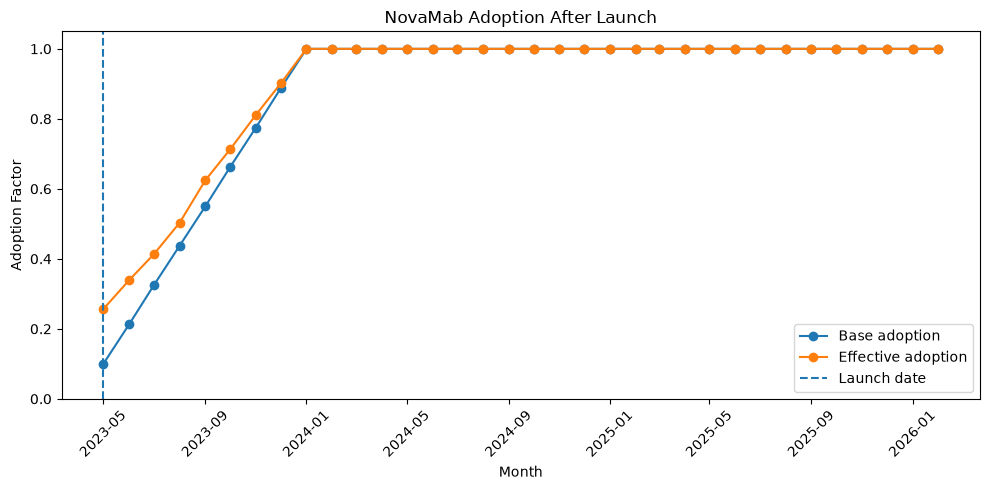

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(
    launch_adoption["month"],
    launch_adoption["base_adoption_factor"],
    marker="o",
    label="Base adoption",
)

plt.plot(
    launch_adoption["month"],
    launch_adoption["effective_adoption_factor"],
    marker="o",
    label="Effective adoption",
)

plt.axvline(
    launch_date,
    linestyle="--",
    label="Launch date",
)

plt.title("NovaMab Adoption After Launch")
plt.xlabel("Month")
plt.ylabel("Adoption Factor")
plt.ylim(0, 1.05)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

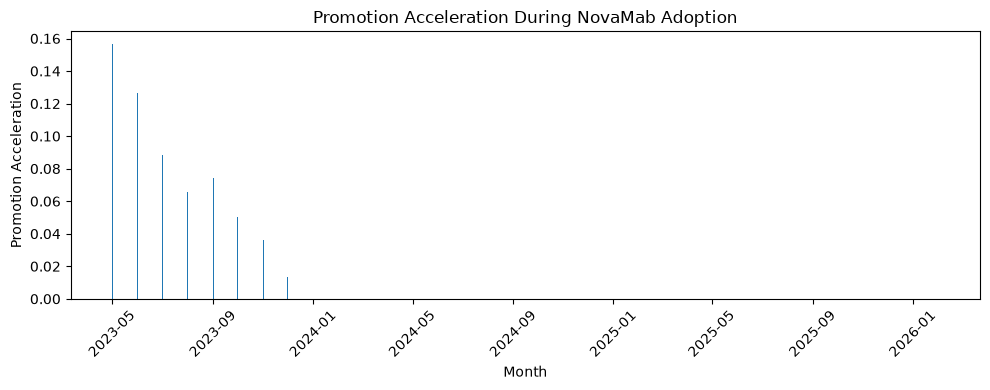

In [12]:
plt.figure(figsize=(10, 4))

plt.bar(
    launch_adoption["month"],
    launch_adoption["promotion_acceleration"],
)

plt.title("Promotion Acceleration During NovaMab Adoption")
plt.xlabel("Month")
plt.ylabel("Promotion Acceleration")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
assert (
    launch_adoption["effective_adoption_factor"] >= launch_adoption["base_adoption_factor"]
).all()

assert (launch_adoption["effective_adoption_factor"] <= 1.0).all()

print("Effective adoption never falls below base adoption.")
print("Effective adoption never exceeds full adoption.")

Effective adoption never falls below base adoption.
Effective adoption never exceeds full adoption.


### Interpreting the Adoption Curves

The base adoption curve describes how NovaMab would mature without promotional acceleration.

Promotional activity increases the effective adoption factor during the early launch period. The effect becomes smaller as the product approaches full adoption because there is less remaining adoption gap to close.

Once the base adoption factor reaches `1.0`, promotion can no longer increase adoption further.

This distinction is important:

- adoption describes product maturity
- market share describes the observed competitive outcome

A product can therefore have a high adoption factor without holding exactly the same percentage of market share.

## Market Share Evolution

Market share is one of the most visible measures of commercial performance.

HealthSynth calculates market share in several stages:

```text
Baseline Share
        +
Promotion Effect
        +
Launch Adoption
        ↓
Raw Competitive Score
        ↓
Competitive Redistribution
        ↓
Adjusted Market Share
```

The adjusted market share represents the competitive position used later during prescription allocation.

Unlike a simple random simulation, every month's market share is produced from explicit commercial behaviour.

In [15]:
market_share_named = market_share.merge(
    products[
        [
            "product_id",
            "product_name",
        ]
    ],
    on="product_id",
    how="left",
)

market_share_plot = market_share_named.pivot(
    index="month",
    columns="product_name",
    values="adjusted_market_share",
)

market_share_plot.head()

product_name,NovaMab,OncoNova,Tumora
month,,,
2023-03-01,0.000000,0.554917,0.445083
2023-04-01,0.000000,0.543391,0.456609
2023-05-01,0.069324,0.537978,0.392699
2023-06-01,0.081627,0.523710,0.394662
2023-07-01,0.107709,0.515617,0.376674


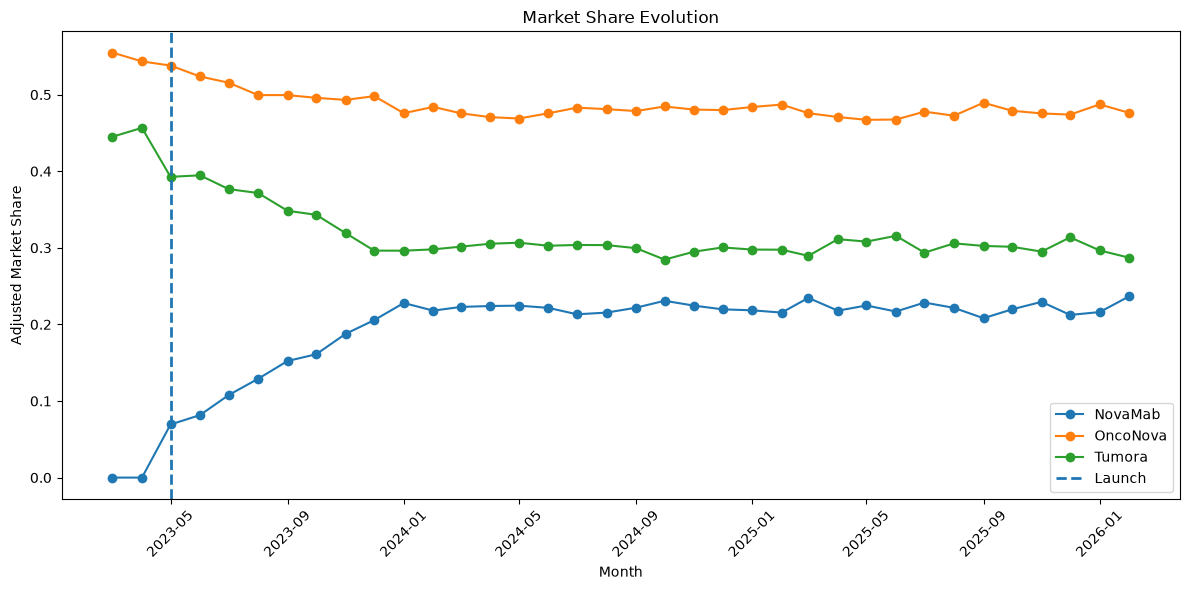

In [16]:
plt.figure(figsize=(12, 6))

for column in market_share_plot.columns:
    plt.plot(
        market_share_plot.index,
        market_share_plot[column],
        marker="o",
        label=column,
    )

plt.axvline(
    launch_date,
    linestyle="--",
    linewidth=2,
    label="Launch",
)

plt.title("Market Share Evolution")
plt.xlabel("Month")
plt.ylabel("Adjusted Market Share")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Observations

Several commercial behaviours become visible.

- NovaMab has zero share before launch.
- Following launch, market share increases gradually rather than immediately reaching its mature level.
- Promotion accelerates adoption during the early launch period.
- Existing competitors lose market share as NovaMab gains traction.
- Total market share remains fully allocated every month.

## Where Does the New Product's Share Come From?

When a new product enters the market, its market share cannot appear from nowhere.

Every percentage point gained by the launch product must be sourced from existing competitors.

HealthSynth makes this relationship configurable through competitive share sourcing.

Instead of assuming that all competitors lose share equally, the simulation allows the launch product to draw different proportions from each incumbent.

In [17]:
share_comparison = (
    market_share_named[
        market_share_named["month"].isin(
            [
                pd.Timestamp("2023-04-01"),
                pd.Timestamp("2023-08-01"),
            ]
        )
    ]
    .pivot(
        index="product_name",
        columns="month",
        values="adjusted_market_share",
    )
    .rename(
        columns={
            pd.Timestamp("2023-04-01"): "pre_launch_share",
            pd.Timestamp("2023-08-01"): "post_launch_share",
        }
    )
)

share_comparison["share_change"] = (
    share_comparison["post_launch_share"] - share_comparison["pre_launch_share"]
)

share_comparison

month,pre_launch_share,post_launch_share,share_change
product_name,,,
NovaMab,0.000000,0.128991,0.128991
OncoNova,0.543391,0.499447,-0.043945
Tumora,0.456609,0.371562,-0.085047


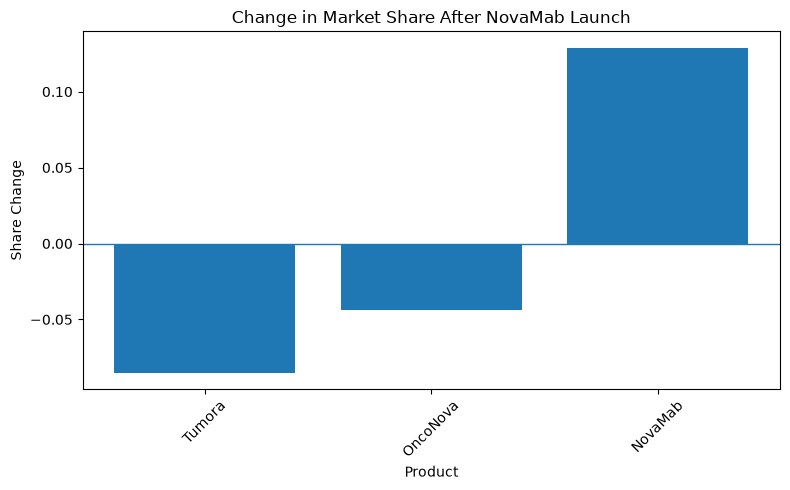

In [18]:
share_change_plot = share_comparison["share_change"].sort_values().reset_index()

plt.figure(figsize=(8, 5))

plt.bar(
    share_change_plot["product_name"],
    share_change_plot["share_change"],
)

plt.axhline(0, linewidth=1)

plt.title("Change in Market Share After NovaMab Launch")
plt.xlabel("Product")
plt.ylabel("Share Change")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpreting Competitive Displacement

NovaMab gains share gradually after launch, while both incumbent products lose share.

Tumora experiences the larger decline because the scenario assigns it a higher share-source weight.

This reflects an important commercial reality: a new product does not necessarily compete equally with every incumbent. Clinical positioning, patient segment, mechanism of action, access, and promotional strategy may make one competitor more exposed than another.

## From Market Share to Prescriptions

Adjusted market share is not merely a reporting output.

HealthSynth uses it to allocate monthly market demand across products:

```text
Monthly Market NRx
        ×
Adjusted Market Share
        =
Product NRx
        ↓
Allocated Across HCPs

In [19]:
rx_named = prescriptions.merge(
    products[
        [
            "product_id",
            "product_name",
        ]
    ],
    on="product_id",
    how="left",
)

monthly_rx = (
    rx_named.groupby(
        [
            "rx_date",
            "product_name",
        ]
    )["nrx"]
    .sum()
    .reset_index()
)

monthly_rx.head()

,rx_date,product_name,nrx
0,2023-03-01,NovaMab,0
1,2023-03-01,OncoNova,383
2,2023-03-01,Tumora,315
3,2023-04-01,NovaMab,0
4,2023-04-01,OncoNova,391


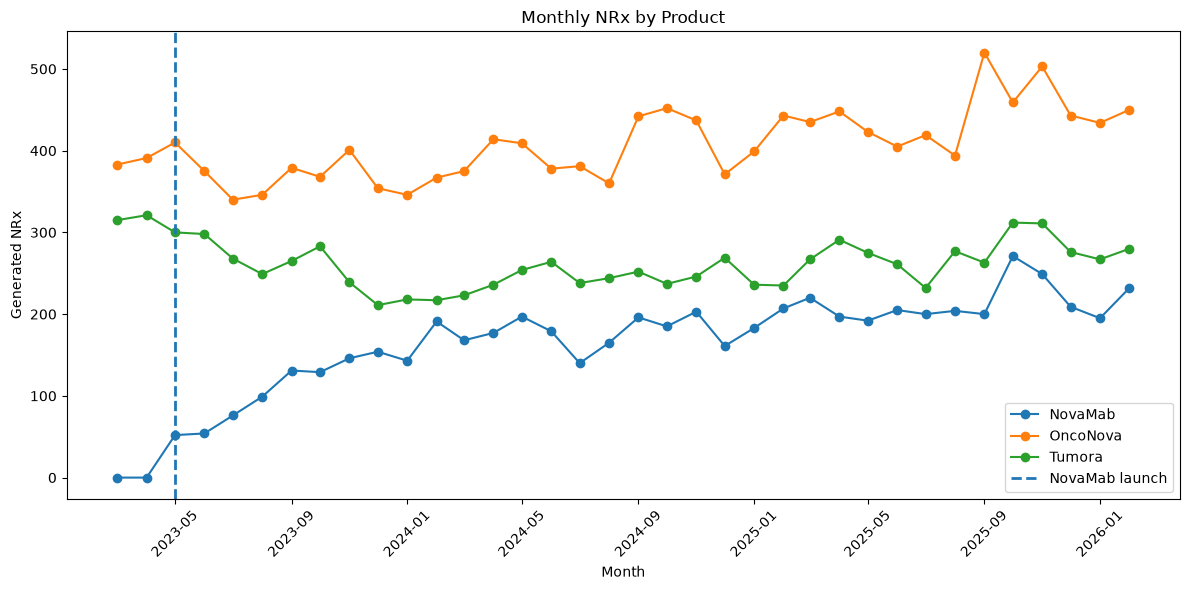

In [20]:
rx_plot = monthly_rx.pivot(
    index="rx_date",
    columns="product_name",
    values="nrx",
)

plt.figure(figsize=(12, 6))

for column in rx_plot.columns:
    plt.plot(
        rx_plot.index,
        rx_plot[column],
        marker="o",
        label=column,
    )

plt.axvline(
    launch_date,
    linestyle="--",
    linewidth=2,
    label="NovaMab launch",
)

plt.title("Monthly NRx by Product")
plt.xlabel("Month")
plt.ylabel("Generated NRx")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
novamab_rx = monthly_rx[monthly_rx["product_name"] == "NovaMab"].copy()

novamab_rx.head(10)

,rx_date,product_name,nrx
0,2023-03-01,NovaMab,0
3,2023-04-01,NovaMab,0
6,2023-05-01,NovaMab,52
9,2023-06-01,NovaMab,54
12,2023-07-01,NovaMab,76
15,2023-08-01,NovaMab,99
18,2023-09-01,NovaMab,131
21,2023-10-01,NovaMab,129
24,2023-11-01,NovaMab,146
27,2023-12-01,NovaMab,154


## Demand Reconciliation

The prescription generator does not create market volume independently.

For each month, total generated NRx should reconcile exactly with the simulated market demand.

This ensures that product launches and competitive changes affect how demand is distributed, but do not create unexplained prescriptions outside the upstream commercial model.

In [23]:
monthly_generated_nrx = (
    prescriptions.groupby("rx_date")["nrx"]
    .sum()
    .reset_index(name="generated_nrx")
    .rename(columns={"rx_date": "month"})
)

monthly_generated_nrx["month"] = pd.to_datetime(monthly_generated_nrx["month"])

market_demand_reconciliation = market_demand[
    [
        "month",
        "market_nrx",
    ]
].copy()

market_demand_reconciliation["month"] = pd.to_datetime(market_demand_reconciliation["month"])

demand_reconciliation = market_demand_reconciliation.merge(
    monthly_generated_nrx,
    on="month",
    how="left",
)

demand_reconciliation["difference"] = (
    demand_reconciliation["generated_nrx"] - demand_reconciliation["market_nrx"]
)

demand_reconciliation.head()

,month,market_nrx,generated_nrx,difference
0,2023-03-01,698,698,0
1,2023-04-01,712,712,0
2,2023-05-01,762,762,0
3,2023-06-01,727,727,0
4,2023-07-01,684,684,0


In [24]:
assert (demand_reconciliation["difference"] == 0).all()

print("Monthly generated NRx reconciles exactly with market demand.")

Monthly generated NRx reconciles exactly with market demand.


## Business Insight
A successful product launch should not be interpreted only through launch-product growth.
Commercial analysts should also examine:
- how quickly adoption develops
- whether promotion accelerates uptake
- which competitors lose share
- whether prescription growth reflects market expansion or competitive displacement
- whether the product is approaching its mature commercial potential

A launch can appear successful in absolute prescription volume while still underperforming relative to market growth or expected adoption.

## Key Takeaways

- Product availability begins at the configured launch date.
- Pre-launch market share, prescriptions, and promotional calls remain zero.
- Adoption develops gradually rather than appearing instantly.
- Promotional activity can accelerate adoption while preserving a maximum factor of `1.0`.
- Launch-product share is explicitly sourced from incumbent competitors.
- Different competitors may experience different levels of displacement.
- Adjusted market share drives product-level prescription allocation.
- Monthly generated NRx reconciles exactly with upstream market demand.

This scenario demonstrates HealthSynth's central design philosophy:

```text
Define a commercial world
        ↓
Simulate commercial behaviour
        ↓
Generate internally consistent datasets
        ↓
Analyse the resulting outcomes